In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import ROOT
plt.style.use("style.mplstyle")


Bad value in file 'style.mplstyle', line 47 ('grid.color: #CCCCCC'): Key grid.color: '' does not look like a color arg
Bad value in file 'style.mplstyle', line 74 ("axes.prop_cycle: cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])"): Key axes.prop_cycle: 'cycler('color', ['' is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


Welcome to JupyROOT 6.26/02


In [159]:
dataset = baseClasses.Data()

In [160]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 15)) & (dataset.data.index < datetime.datetime(2024, 8, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [161]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")

Initializing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.44sensor/s]


In [162]:
tgrad.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_OCTOBER")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.70sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 83.03sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.01sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_OCTOBER:  83%|████████▎ | 20/24 [00:00<00:00, 96.20sensor/s]

ERROR: SensorID (40000) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40001) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40002) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40003) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40004) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40005) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40006) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40007) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40008) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40009) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40010) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40011) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40012) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40013) not found in calibration (SECOND_POFF_OCTOBER)
ERROR:

Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 24/24 [00:00<00:00, 94.87sensor/s]

ERROR: SensorID (40020) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40021) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40022) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40023) not found in calibration (SECOND_POFF_OCTOBER)


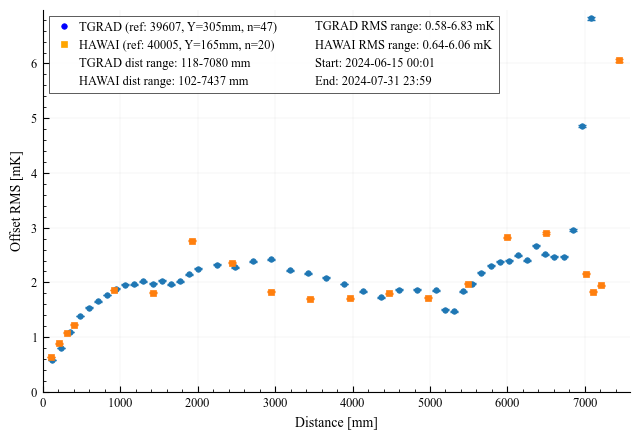

In [166]:
# Calculate RMS for all differences within each system using specific reference sensors
# TGRAD system: use sensor 39607 as reference
# HAWAI system: use sensor 40005 as reference

# Check if reference sensors exist
if 39607 not in tgrad.sensors:
    raise ValueError("Reference sensor 39607 not found in TGRAD system")
if 40005 not in hawai.sensors:
    raise ValueError("Reference sensor 40005 not found in HAWAI system")

# Get reference sensors
tgrad_ref = tgrad.sensors[39607]
hawai_ref = hawai.sensors[40005]

# Calculate RMS for TGRAD system (all sensors vs 39607)
tgrad_distances = []
tgrad_rms_values = []
tgrad_rms_errors = []

for sensor_id, sensor in tgrad.sensors.items():
    if sensor_id == 39607:  # Skip reference sensor itself
        continue

    # Calculate distance
    distance = np.sqrt((sensor.X - tgrad_ref.X)**2 + (sensor.Y - tgrad_ref.Y)**2 + (sensor.Z - tgrad_ref.Z)**2)

    # Calculate difference
    diff = sensor.data - tgrad_ref.data

        # Calculate RMS and its error
    rms = diff.std()
    rms_error = rms / np.sqrt(len(diff))  # Standard error of the mean for RMS

    # Filter out values larger than 10 mK
    if rms <= 0.01:  # 10 mK = 0.01 K
        tgrad_distances.append(distance)
        tgrad_rms_values.append(rms)
        tgrad_rms_errors.append(rms_error)

# Calculate RMS for HAWAI system (all sensors vs 40005)
hawai_distances = []
hawai_rms_values = []
hawai_rms_errors = []

for sensor_id, sensor in hawai.sensors.items():
    if sensor_id == 40005:  # Skip reference sensor itself
        continue

    # Calculate distance
    distance = np.sqrt((sensor.X - hawai_ref.X)**2 + (sensor.Y - hawai_ref.Y)**2 + (sensor.Z - hawai_ref.Z)**2)

    # Calculate difference
    diff = sensor.data - hawai_ref.data

        # Calculate RMS and its error
    rms = diff.std()
    rms_error = rms / np.sqrt(len(diff))  # Standard error of the mean for RMS

    # Filter out values larger than 10 mK
    if rms <= 0.01:  # 10 mK = 0.01 K
        hawai_distances.append(distance)
        hawai_rms_values.append(rms)
        hawai_rms_errors.append(rms_error)

# Convert to numpy arrays
tgrad_distances = np.array(tgrad_distances)
tgrad_rms_values = np.array(tgrad_rms_values)
tgrad_rms_errors = np.array(tgrad_rms_errors)

hawai_distances = np.array(hawai_distances)
hawai_rms_values = np.array(hawai_rms_values)
hawai_rms_errors = np.array(hawai_rms_errors)

# Create the plot
fig, ax = plt.subplots(1, 1)

# Plot TGRAD data
ax.errorbar(tgrad_distances, 1e3*tgrad_rms_values, yerr=1e3*tgrad_rms_errors,
           fmt='o', markersize=4, capsize=3, capthick=1,
           label=f'TGRAD (ref: 39607, n={len(tgrad_distances)})')

# Plot HAWAI data
ax.errorbar(hawai_distances, 1e3*hawai_rms_values, yerr=1e3*hawai_rms_errors,
           fmt='s', markersize=4, capsize=3, capthick=1,
           label=f'HAWAI (ref: 40005, n={len(hawai_distances)})')

# Formatting
ax.set_xlabel("Distance [mm]")
ax.set_ylabel("Offset RMS [mK]")
ax.set_ylim(0)
ax.set_xlim(0)
# ax.set_title("RMS Residual vs Distance\nTGRAD (ref: 39607) and HAWAI (ref: 40005)")
ax.legend()
ax.grid(True, alpha=0.3)

# Get time range from the data
time_index = tgrad_ref.data.index
start_time = time_index[0]
end_time = time_index[-1]

# Add statistics to legend
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', linestyle='None', label=f'TGRAD (ref: 39607, Y={tgrad_ref.Y:.0f}mm, n={len(tgrad_distances)})'),
    plt.Line2D([0], [0], color='orange', marker='s', linestyle='None', label=f'HAWAI (ref: 40005, Y={hawai_ref.Y:.0f}mm, n={len(hawai_distances)})'),
    plt.Line2D([0], [0], color='none', label=f'TGRAD dist range: {np.min(tgrad_distances):.0f}-{np.max(tgrad_distances):.0f} mm'),
    plt.Line2D([0], [0], color='none', label=f'HAWAI dist range: {np.min(hawai_distances):.0f}-{np.max(hawai_distances):.0f} mm'),
    plt.Line2D([0], [0], color='none', label=f'TGRAD RMS range: {np.min(tgrad_rms_values)*1000:.2f}-{np.max(tgrad_rms_values)*1000:.2f} mK'),
    plt.Line2D([0], [0], color='none', label=f'HAWAI RMS range: {np.min(hawai_rms_values)*1000:.2f}-{np.max(hawai_rms_values)*1000:.2f} mK'),
    plt.Line2D([0], [0], color='none', label=f'Start: {start_time.strftime("%Y-%m-%d %H:%M")}'),
    plt.Line2D([0], [0], color='none', label=f'End: {end_time.strftime("%Y-%m-%d %H:%M")}')
]

ax.legend(handles=legend_elements, loc='best', ncol=2)

plt.tight_layout()
plt.show()

fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/CALIBRATION/performance_resolution_first.png", dpi=300, format="png")


In [194]:
# Plot mean RMS vs window size for ascending time windows
# Calculate RMS for different window sizes: 5, 10, 15, 20, 30, 45, 60... minutes

# Calculate total duration first
max_duration_minutes = (time_index[-1] - time_index[0]).total_seconds() / 60

# Define ascending window sizes in minutes with more points
# Start with small increments, then larger ones
window_sizes_minutes = []

# Small windows: 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60
for i in range(5, 61, 5):
    window_sizes_minutes.append(i)

# Medium windows: 75, 90, 105, 120, 135, 150, 165, 180
for i in range(75, 181, 15):
    window_sizes_minutes.append(i)

# Larger windows: 240, 300, 360, 420, 480, 540, 600, 720
for i in range(240, 721, 60):
    window_sizes_minutes.append(i)

# Very large windows: 900, 1080, 1260, 1440, 1800, 2160, 2520, 2880
for i in range(900, 2881, 180):
    window_sizes_minutes.append(i)

# Add 2-3 points between 2880 and total duration
if max_duration_minutes > 2880:
    # Calculate 2-3 evenly spaced points between 2880 and total duration
    remaining_duration = max_duration_minutes - 2880
    if remaining_duration > 0:
        # Add 2 intermediate points
        step = remaining_duration / 3
        for i in range(1, 3):  # Add 2 points
            point = 2880 + i * step
            if point < max_duration_minutes:
                window_sizes_minutes.append(int(point))

# Add the total duration as the largest window
window_sizes_minutes.append(int(max_duration_minutes))

# Remove duplicates and sort
window_sizes_minutes = sorted(list(set(window_sizes_minutes)))

# Filter out window sizes larger than the total duration
valid_window_sizes = [w for w in window_sizes_minutes if w <= max_duration_minutes]

print(f"Analyzing window sizes: {valid_window_sizes} minutes")
print(f"Maximum duration: {max_duration_minutes:.1f} minutes")

# Get specific sensor pairs (same as Cell 5)
# TGRAD: 39607-39608
# HAWAI: 40005-40004

# Check if specific sensors exist
if 39607 not in tgrad.sensors or 39608 not in tgrad.sensors:
    raise ValueError("Sensors 39607 or 39608 not found in TGRAD system")
if 40005 not in hawai.sensors or 40004 not in hawai.sensors:
    raise ValueError("Sensors 40005 or 40004 not found in HAWAI system")

# Get specific sensors
tgrad_sensor1 = tgrad.sensors[39607]
tgrad_sensor2 = tgrad.sensors[39608]
hawai_sensor1 = hawai.sensors[40005]
hawai_sensor2 = hawai.sensors[40004]

# Calculate differences for the specific pairs
tgrad_diff = tgrad_sensor1.data - tgrad_sensor2.data
hawai_diff = hawai_sensor1.data - hawai_sensor2.data

# Get time index from TGRAD data
time_index = tgrad_diff.index

# Check if HAWAI has data in the same time range
hawai_has_data = len(hawai_diff) > 0
if hawai_has_data:
    # Find common time range between TGRAD and HAWAI
    common_start = max(time_index[0], hawai_diff.index[0])
    common_end = min(time_index[-1], hawai_diff.index[-1])
    print(f"HAWAI data available from {hawai_diff.index[0]} to {hawai_diff.index[-1]}")
    print(f"Common time range: {common_start} to {common_end}")
else:
    print("HAWAI has no data in the specified time range")

# Calculate mean RMS and RMS of RMSs for each window size
window_size_results = []

for window_size_min in valid_window_sizes:
    window_td = pd.Timedelta(minutes=window_size_min)

    # Calculate number of windows that fit in the total duration
    num_windows = int(max_duration_minutes / window_size_min)

    if num_windows < 1:
        continue

    # Collect RMS values for TGRAD and HAWAI
    tgrad_rms_values = []
    hawai_rms_values = []

    for window_idx in range(num_windows):
        # Calculate window start and end times
        window_start = time_index[0] + pd.Timedelta(minutes=window_idx * window_size_min)
        window_end = window_start + window_td

        # Ensure we don't go beyond the data range
        if window_end > time_index[-1]:
            window_end = time_index[-1]

        # Get data in this window
        mask = (time_index >= window_start) & (time_index < window_end)

        # Calculate RMS for TGRAD pair (39607-39608)
        window_diff = tgrad_diff[mask]

        if len(window_diff) > 0:
            rms_val = window_diff.std()
            # Filter out values larger than 10 mK
            if rms_val <= 0.01:  # 10 mK = 0.01 K
                tgrad_rms_values.append(rms_val)

        # Calculate RMS for HAWAI pair (40005-40004) if data is available
        if hawai_has_data:
            # Check if this window overlaps with HAWAI data
            hawai_mask = (hawai_diff.index >= window_start) & (hawai_diff.index < window_end)
            hawai_window_diff = hawai_diff[hawai_mask]

            if len(hawai_window_diff) > 0:
                hawai_rms_val = hawai_window_diff.std()
                # Filter out values larger than 10 mK
                if hawai_rms_val <= 0.01:  # 10 mK = 0.01 K
                    hawai_rms_values.append(hawai_rms_val)

    # Special case: if this is the total duration window, calculate RMS over the entire dataset
    if window_size_min == int(max_duration_minutes):
        # Calculate RMS over the entire dataset for TGRAD
        if len(tgrad_diff) > 0:
            rms_val = tgrad_diff.std()
            # Filter out values larger than 10 mK
            if rms_val <= 0.01:  # 10 mK = 0.01 K
                tgrad_rms_values = [rms_val]  # Single value for the entire dataset

        # Calculate RMS over the entire dataset for HAWAI
        if hawai_has_data and len(hawai_diff) > 0:
            hawai_rms_val = hawai_diff.std()
            # Filter out values larger than 10 mK
            if hawai_rms_val <= 0.01:  # 10 mK = 0.01 K
                hawai_rms_values = [hawai_rms_val]  # Single value for the entire dataset

    # Calculate statistics for this window size
    tgrad_stats = None
    hawai_stats = None

    if len(tgrad_rms_values) > 0:
        tgrad_mean_rms = np.mean(tgrad_rms_values)
        tgrad_rms_of_rms = np.std(tgrad_rms_values)
        tgrad_num_windows = len(tgrad_rms_values)
        tgrad_stats = {
            'mean_rms': tgrad_mean_rms,
            'rms_of_rms': tgrad_rms_of_rms,
            'num_windows': tgrad_num_windows
        }

    if len(hawai_rms_values) > 0:
        hawai_mean_rms = np.mean(hawai_rms_values)
        hawai_rms_of_rms = np.std(hawai_rms_values)
        hawai_num_windows = len(hawai_rms_values)
        hawai_stats = {
            'mean_rms': hawai_mean_rms,
            'rms_of_rms': hawai_rms_of_rms,
            'num_windows': hawai_num_windows
        }

    window_size_results.append({
        'window_size_min': window_size_min,
        'window_size_hours': window_size_min / 60,
        'tgrad_stats': tgrad_stats,
        'hawai_stats': hawai_stats
    })

    # Print statistics
    tgrad_str = f"TGRAD: {tgrad_stats['mean_rms']*1000:6.2f}±{tgrad_stats['rms_of_rms']*1000:6.2f} mK (N={tgrad_stats['num_windows']})" if tgrad_stats else "TGRAD: No data"
    hawai_str = f"HAWAI: {hawai_stats['mean_rms']*1000:6.2f}±{hawai_stats['rms_of_rms']*1000:6.2f} mK (N={hawai_stats['num_windows']})" if hawai_stats else "HAWAI: No data"
    print(f"Window {window_size_min:4d} min: {tgrad_str}, {hawai_str}")

# Separate data for plotting
tgrad_window_sizes = []
tgrad_mean_rms = []
tgrad_rms_of_rms = []
hawai_window_sizes = []
hawai_mean_rms = []
hawai_rms_of_rms = []

for result in window_size_results:
    if result['tgrad_stats']:
        tgrad_window_sizes.append(result['window_size_hours'])
        tgrad_mean_rms.append(result['tgrad_stats']['mean_rms'])
        tgrad_rms_of_rms.append(result['tgrad_stats']['rms_of_rms'])

    if result['hawai_stats']:
        hawai_window_sizes.append(result['window_size_hours'])
        hawai_mean_rms.append(result['hawai_stats']['mean_rms'])
        hawai_rms_of_rms.append(result['hawai_stats']['rms_of_rms'])

# Convert to arrays for plotting
tgrad_window_sizes = np.array(tgrad_window_sizes)
tgrad_mean_rms = np.array(tgrad_mean_rms)
tgrad_rms_of_rms = np.array(tgrad_rms_of_rms)
hawai_window_sizes = np.array(hawai_window_sizes)
hawai_mean_rms = np.array(hawai_mean_rms)
hawai_rms_of_rms = np.array(hawai_rms_of_rms)

# Create the plot
fig, ax = plt.subplots(1, 1)

# Calculate sensor information for legend
def get_sensor_info(system, sensor1, sensor2):
    # Find bottom-most sensor (lowest Y coordinate)
    if sensor1.Y < sensor2.Y:
        bottom_height = sensor1.Y
    else:
        bottom_height = sensor2.Y

    # Calculate distance between sensors
    distance = np.sqrt((sensor1.X - sensor2.X)**2 + (sensor1.Y - sensor2.Y)**2 + (sensor1.Z - sensor2.Z)**2)

    return bottom_height, distance

# Get sensor information
tgrad_bottom_height, tgrad_distance = get_sensor_info(tgrad, tgrad_sensor1, tgrad_sensor2)
hawai_bottom_height, hawai_distance = get_sensor_info(hawai, hawai_sensor1, hawai_sensor2)

# Plot mean RMS vs window size for TGRAD
if len(tgrad_window_sizes) > 0:
    ax.errorbar(tgrad_window_sizes, tgrad_mean_rms * 1000, yerr=tgrad_rms_of_rms * 1000,
               fmt='o-', markersize=6, capsize=4, capthick=1.5, alpha=0.8, color='blue',
               label='TGRAD: 39607-39608')

# Plot mean RMS vs window size for HAWAI
if len(hawai_window_sizes) > 0:
    ax.errorbar(hawai_window_sizes, hawai_mean_rms * 1000, yerr=hawai_rms_of_rms * 1000,
               fmt='s-', markersize=6, capsize=4, capthick=1.5, alpha=0.8, color='orange',
               label='HAWAI: 40005-40004')

# Formatting
ax.set_xlabel('Window Size [hours]')
ax.set_ylabel('Mean RMS [mK]')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Create legend with statistics
legend_elements = []
if len(tgrad_window_sizes) > 0:
    legend_elements.append(plt.Line2D([0], [0], color='blue', marker='o', linestyle='-',
                   label=f'TGRAD: 39607-39608 (H={tgrad_bottom_height:.0f}mm, d={tgrad_distance:.0f}mm)'))
if len(hawai_window_sizes) > 0:
    legend_elements.append(plt.Line2D([0], [0], color='orange', marker='s', linestyle='-',
                   label=f'HAWAI: 40005-40004 (H={hawai_bottom_height:.0f}mm, d={hawai_distance:.0f}mm)'))

legend_elements.extend([
    plt.Line2D([0], [0], color='none', label=f'Window sizes: {len(valid_window_sizes)}'),
    plt.Line2D([0], [0], color='none', label=f'Total duration: {max_duration_minutes/60:.1f} h'),
    plt.Line2D([0], [0], color='none', label=f'Start: {time_index[0].strftime("%Y-%m-%d %H:%M")}'),
    plt.Line2D([0], [0], color='none', label=f'End: {time_index[-1].strftime("%Y-%m-%d %H:%M")}')
])

ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/CALIBRATION/performance_resolution_window_size.png", dpi=300, format="png")
# Summary statistics
print(f"\nMean RMS vs Window Size Analysis:")
print(f"TGRAD: 39607-39608 (Bottom height: {tgrad_bottom_height:.0f}mm, Distance: {tgrad_distance:.0f}mm)")
if hawai_has_data:
    print(f"HAWAI: 40005-40004 (Bottom height: {hawai_bottom_height:.0f}mm, Distance: {hawai_distance:.0f}mm)")
else:
    print("HAWAI: No data available")
print(f"Total duration: {max_duration_minutes/60:.1f} hours")
print(f"Window sizes analyzed: {len(valid_window_sizes)}")
print(f"TGRAD data points: {len(tgrad_window_sizes)}")
print(f"HAWAI data points: {len(hawai_window_sizes)}")
print(f"Each point represents RMS for the specific sensor pair in windows of that size")
print(f"Error bars represent RMS of RMSs (variability across windows)")
print(f"Largest window points should match Cell 5 points")


Analyzing window sizes: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 75, 90, 105, 120, 135, 150, 165, 180, 240, 300, 360, 420, 480, 540, 600, 660, 720, 900, 1080, 1260, 1440, 1620, 1800, 1980, 2160, 2340, 2520, 2700, 2880, 86879, 170878, 254878] minutes
Maximum duration: 254878.0 minutes
HAWAI data available from 2024-06-01 00:01:00 to 2024-09-14 23:59:00
Common time range: 2024-06-01 00:01:00 to 2024-09-14 23:59:00


KeyboardInterrupt: 

HAWAI data available from 2024-06-01 00:01:00 to 2024-09-14 23:59:00
Analysis:
Total duration: 4248.0 hours
Window size: 12 hours
Number of windows: 353


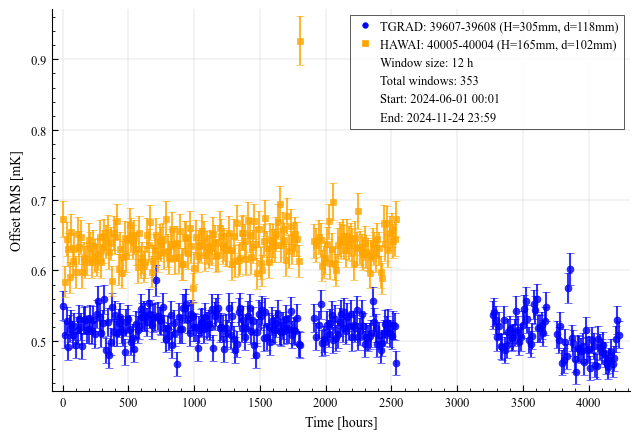


Analysis complete:
TGRAD: 39607-39608 (Bottom height: 305mm, Distance: 118mm)
HAWAI: 40005-40004 (Bottom height: 165mm, Distance: 102mm)
Total time range: 2024-06-01 00:01:00 to 2024-11-24 23:59:00
Duration: 4248.0 hours
Window size: 12 hours
Total windows: 353
Each point represents RMS vs time in 12-hour windows


In [196]:
# Plot TGRAD and HAWAI sensor pairs (39607-39608 and 40005-40004)

# Define sensor pairs
tgrad_sensor_pairs = [(39607, 39608)]  # TGRAD (Valencia)
hawai_sensor_pairs = [(40005, 40004)]  # HAWAI

# Calculate sensor information for legend
def get_sensor_info(system, pair_id):
    sensor1 = system.sensors[pair_id[0]]
    sensor2 = system.sensors[pair_id[1]]

    # Find bottom-most sensor (lowest Y coordinate)
    if sensor1.Y < sensor2.Y:
        bottom_sensor = sensor1
        bottom_height = sensor1.Y
    else:
        bottom_sensor = sensor2
        bottom_height = sensor2.Y

    # Calculate distance between sensors
    distance = np.sqrt((sensor1.X - sensor2.X)**2 + (sensor1.Y - sensor2.Y)**2 + (sensor1.Z - sensor2.Z)**2)

    return bottom_height, distance

# Get sensor information
tgrad_bottom_height, tgrad_distance = get_sensor_info(tgrad, tgrad_sensor_pairs[0])
hawai_bottom_height, hawai_distance = get_sensor_info(hawai, hawai_sensor_pairs[0])

# Calculate differences for TGRAD pair
tgrad_differences = {}
for sensor_id_1, sensor_id_2 in tgrad_sensor_pairs:
    sensor1 = tgrad.sensors[sensor_id_1]
    sensor2 = tgrad.sensors[sensor_id_2]
    tgrad_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

# Calculate differences for HAWAI pair
hawai_differences = {}
for sensor_id_1, sensor_id_2 in hawai_sensor_pairs:
    sensor1 = hawai.sensors[sensor_id_1]
    sensor2 = hawai.sensors[sensor_id_2]
    hawai_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

# Get time index from TGRAD data
time_index = tgrad_differences[list(tgrad_differences.keys())[0]].index

# Check if HAWAI has data
hawai_has_data = len(hawai_differences) > 0 and len(hawai_differences[list(hawai_differences.keys())[0]]) > 0
if hawai_has_data:
    print(f"HAWAI data available from {hawai_differences[list(hawai_differences.keys())[0]].index[0]} to {hawai_differences[list(hawai_differences.keys())[0]].index[-1]}")
else:
    print("HAWAI has no data in the specified time range")

# Define window size (12 hours)
window_size_minutes = 12 * 60  # 12 hours in minutes
window_td = pd.Timedelta(minutes=window_size_minutes)

# Calculate total duration and number of windows
total_duration = time_index[-1] - time_index[0]
num_windows = int(total_duration.total_seconds() / (window_size_minutes * 60))

print(f"Analysis:")
print(f"Total duration: {total_duration.total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Number of windows: {num_windows}")

# Calculate RMS for each sliding window
tgrad_all_rms_results = {}
hawai_all_rms_results = {}

for window_idx in range(num_windows):
    # Calculate window start and end times
    window_start = time_index[0] + pd.Timedelta(minutes=window_idx * window_size_minutes)
    window_end = window_start + window_td

    # Ensure we don't go beyond the data range
    if window_end > time_index[-1]:
        window_end = time_index[-1]

    # Get data in this window
    mask = (time_index >= window_start) & (time_index < window_end)

    # Calculate center time of the window for plotting
    window_center_time = window_start + (window_end - window_start) / 2
    window_center_hours = (window_center_time - time_index[0]).total_seconds() / 3600

    # TGRAD calculation
    tgrad_rms_results = {}
    for pair_id, sensor_diff in tgrad_differences.items():
        window_data = sensor_diff[mask]
        if len(window_data) > 0:
            rms_val = window_data.std()
            rms_error = rms_val / np.sqrt(len(window_data))

            # Filter out values larger than 10 mK
            if rms_val <= 0.01:  # 10 mK = 0.01 K
                tgrad_rms_results[pair_id] = {
                    'rms_value': rms_val,
                    'rms_error': rms_error,
                    'data_points': len(window_data),
                    'window_center_hours': window_center_hours
                }

    tgrad_all_rms_results[window_idx] = tgrad_rms_results

    # HAWAI calculation
    hawai_rms_results = {}
    if hawai_has_data:
        for pair_id, sensor_diff in hawai_differences.items():
            # Check if this window overlaps with HAWAI data
            hawai_mask = (sensor_diff.index >= window_start) & (sensor_diff.index < window_end)
            hawai_window_data = sensor_diff[hawai_mask]

            if len(hawai_window_data) > 0:
                rms_val = hawai_window_data.std()
                rms_error = rms_val / np.sqrt(len(hawai_window_data))

                # Filter out values larger than 10 mK
                if rms_val <= 0.01:  # 10 mK = 0.01 K
                    hawai_rms_results[pair_id] = {
                        'rms_value': rms_val,
                        'rms_error': rms_error,
                        'data_points': len(hawai_window_data),
                        'window_center_hours': window_center_hours
                    }

    hawai_all_rms_results[window_idx] = hawai_rms_results

# Create plot: RMS vs Time for both systems
fig, ax = plt.subplots(1, 1)

# Define colors
tgrad_color = 'blue'
hawai_color = 'orange'

# Plot TGRAD data
for i, pair_id in enumerate(tgrad_sensor_pairs):
    rms_values_mK = []
    rms_errors_mK = []
    time_points = []

    for window_idx in range(num_windows):
        if window_idx in tgrad_all_rms_results and pair_id in tgrad_all_rms_results[window_idx]:
            data = tgrad_all_rms_results[window_idx][pair_id]
            rms_values_mK.append(data['rms_value'] * 1000)  # Convert to mK
            rms_errors_mK.append(data['rms_error'] * 1000)  # Convert to mK
            time_points.append(data['window_center_hours'])
        else:
            rms_values_mK.append(np.nan)
            rms_errors_mK.append(np.nan)
            time_points.append(np.nan)

    # Only plot if we have valid data
    if not all(np.isnan(rms_values_mK)):
        ax.errorbar(time_points, rms_values_mK, yerr=rms_errors_mK,
                   fmt='o', alpha=0.8, markersize=5, color=tgrad_color,
                   label=f'TGRAD: 39607-39608 (H={tgrad_bottom_height:.0f}mm, d={tgrad_distance:.0f}mm)')

# Plot HAWAI data
if hawai_has_data:
    for i, pair_id in enumerate(hawai_sensor_pairs):
        rms_values_mK = []
        rms_errors_mK = []
        time_points = []

        for window_idx in range(num_windows):
            if window_idx in hawai_all_rms_results and pair_id in hawai_all_rms_results[window_idx]:
                data = hawai_all_rms_results[window_idx][pair_id]
                rms_values_mK.append(data['rms_value'] * 1000)  # Convert to mK
                rms_errors_mK.append(data['rms_error'] * 1000)  # Convert to mK
                time_points.append(data['window_center_hours'])
            else:
                rms_values_mK.append(np.nan)
                rms_errors_mK.append(np.nan)
                time_points.append(np.nan)

        # Only plot if we have valid data
        if not all(np.isnan(rms_values_mK)):
            ax.errorbar(time_points, rms_values_mK, yerr=rms_errors_mK,
                       fmt='s', alpha=0.8, markersize=5, color=hawai_color,
                       label=f'HAWAI: 40005-40004 (H={hawai_bottom_height:.0f}mm, d={hawai_distance:.0f}mm)')

# Formatting
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Offset RMS [mK]')
ax.grid(True)

# Create legend with statistics
legend_elements = []
legend_elements.append(plt.Line2D([0], [0], color='blue', marker='o', linestyle='None',
               label=f'TGRAD: 39607-39608 (H={tgrad_bottom_height:.0f}mm, d={tgrad_distance:.0f}mm)'))
if hawai_has_data:
    legend_elements.append(plt.Line2D([0], [0], color='orange', marker='s', linestyle='None',
                   label=f'HAWAI: 40005-40004 (H={hawai_bottom_height:.0f}mm, d={hawai_distance:.0f}mm)'))

legend_elements.extend([
    plt.Line2D([0], [0], color='none', label=f'Window size: {window_size_minutes//60} h'),
    plt.Line2D([0], [0], color='none', label=f'Total windows: {num_windows}'),
    plt.Line2D([0], [0], color='none', label=f'Start: {time_index[0].strftime("%Y-%m-%d %H:%M")}'),
    plt.Line2D([0], [0], color='none', label=f'End: {time_index[-1].strftime("%Y-%m-%d %H:%M")}')
])

ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nAnalysis complete:")
print(f"TGRAD: 39607-39608 (Bottom height: {tgrad_bottom_height:.0f}mm, Distance: {tgrad_distance:.0f}mm)")
if hawai_has_data:
    print(f"HAWAI: 40005-40004 (Bottom height: {hawai_bottom_height:.0f}mm, Distance: {hawai_distance:.0f}mm)")
else:
    print("HAWAI: No data available")
print(f"Total time range: {time_index[0]} to {time_index[-1]}")
print(f"Duration: {(time_index[-1] - time_index[0]).total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Total windows: {num_windows}")
print(f"Each point represents RMS vs time in {window_size_minutes//60}-hour windows")


TGRAD Analysis:
Total duration: 4344.0 hours
Window size: 12 hours
Number of windows: 361
Number of sensor pairs: 3


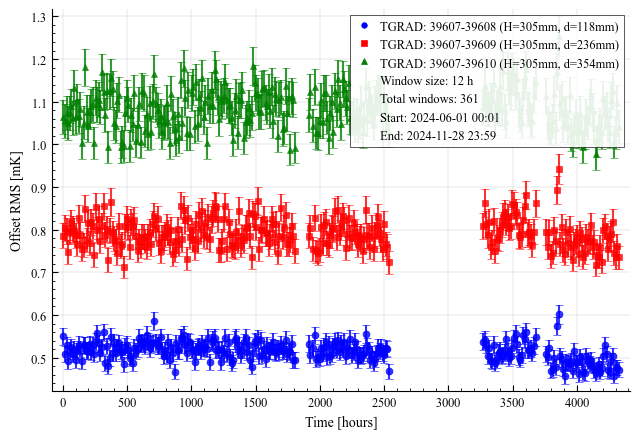


TGRAD Analysis complete:
TGRAD: 39607-39608 (Bottom height: 305mm, Distance: 118mm)
TGRAD: 39607-39609 (Bottom height: 305mm, Distance: 236mm)
TGRAD: 39607-39610 (Bottom height: 305mm, Distance: 354mm)
Total time range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
Duration: 4344.0 hours
Window size: 12 hours
Total windows: 361
Each point represents RMS vs time in 12-hour windows


In [215]:
# Plot TGRAD sensor pairs (39607-39608, 39607-39609, 39607-39610)

# Define TGRAD sensor pairs
tgrad_sensor_pairs = [(39607, 39608), (39607, 39609), (39607, 39610)]  # TGRAD (Valencia)

# Calculate sensor information for legend
def get_sensor_info(system, pair_id):
    sensor1 = system.sensors[pair_id[0]]
    sensor2 = system.sensors[pair_id[1]]

    # Find bottom-most sensor (lowest Y coordinate)
    if sensor1.Y < sensor2.Y:
        bottom_sensor = sensor1
        bottom_height = sensor1.Y
    else:
        bottom_sensor = sensor2
        bottom_height = sensor2.Y

    # Calculate distance between sensors
    distance = np.sqrt((sensor1.X - sensor2.X)**2 + (sensor1.Y - sensor2.Y)**2 + (sensor1.Z - sensor2.Z)**2)

    return bottom_height, distance

# Get sensor information for all pairs
tgrad_sensor_info = {}
for pair_id in tgrad_sensor_pairs:
    tgrad_sensor_info[pair_id] = get_sensor_info(tgrad, pair_id)

# Calculate differences for all TGRAD pairs
tgrad_differences = {}
for sensor_id_1, sensor_id_2 in tgrad_sensor_pairs:
    sensor1 = tgrad.sensors[sensor_id_1]
    sensor2 = tgrad.sensors[sensor_id_2]
    tgrad_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

# Get time index
time_index = tgrad_differences[list(tgrad_differences.keys())[0]].index

# Define window size (12 hours)
window_size_minutes = 12 * 60  # 12 hours in minutes
window_td = pd.Timedelta(minutes=window_size_minutes)

# Calculate total duration and number of windows
total_duration = time_index[-1] - time_index[0]
num_windows = int(total_duration.total_seconds() / (window_size_minutes * 60))

print(f"TGRAD Analysis:")
print(f"Total duration: {total_duration.total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Number of windows: {num_windows}")
print(f"Number of sensor pairs: {len(tgrad_sensor_pairs)}")

# Calculate RMS for each sliding window
tgrad_all_rms_results = {}

for window_idx in range(num_windows):
    # Calculate window start and end times
    window_start = time_index[0] + pd.Timedelta(minutes=window_idx * window_size_minutes)
    window_end = window_start + window_td

    # Ensure we don't go beyond the data range
    if window_end > time_index[-1]:
        window_end = time_index[-1]

    # Get data in this window
    mask = (time_index >= window_start) & (time_index < window_end)

    # Calculate center time of the window for plotting
    window_center_time = window_start + (window_end - window_start) / 2
    window_center_hours = (window_center_time - time_index[0]).total_seconds() / 3600

    # TGRAD calculation
    tgrad_rms_results = {}
    for pair_id, sensor_diff in tgrad_differences.items():
        window_data = sensor_diff[mask]
        if len(window_data) > 0:
            rms_val = window_data.std()
            rms_error = rms_val / np.sqrt(len(window_data))

            # Filter out values larger than 10 mK
            if rms_val <= 0.01:  # 10 mK = 0.01 K
                tgrad_rms_results[pair_id] = {
                    'rms_value': rms_val,
                    'rms_error': rms_error,
                    'data_points': len(window_data),
                    'window_center_hours': window_center_hours
                }

    tgrad_all_rms_results[window_idx] = tgrad_rms_results

# Create plot: RMS vs Time for all TGRAD pairs
fig, ax = plt.subplots(1, 1)

# Define colors for different pairs
colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']

# Plot TGRAD data for all pairs
for i, pair_id in enumerate(tgrad_sensor_pairs):
    rms_values_mK = []
    rms_errors_mK = []
    time_points = []

    for window_idx in range(num_windows):
        if window_idx in tgrad_all_rms_results and pair_id in tgrad_all_rms_results[window_idx]:
            data = tgrad_all_rms_results[window_idx][pair_id]
            rms_values_mK.append(data['rms_value'] * 1000)  # Convert to mK
            rms_errors_mK.append(data['rms_error'] * 1000)  # Convert to mK
            time_points.append(data['window_center_hours'])
        else:
            rms_values_mK.append(np.nan)
            rms_errors_mK.append(np.nan)
            time_points.append(np.nan)

    # Only plot if we have valid data
    if not all(np.isnan(rms_values_mK)):
        bottom_height, distance = tgrad_sensor_info[pair_id]
        ax.errorbar(time_points, rms_values_mK, yerr=rms_errors_mK,
                   fmt=markers[i], alpha=0.8, markersize=5, color=colors[i],
                   label=f'TGRAD: {pair_id[0]}-{pair_id[1]} (H={bottom_height:.0f}mm, d={distance:.0f}mm)')

# Formatting
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Offset RMS [mK]')
ax.grid(True)

# Create legend with statistics
legend_elements = []
for i, pair_id in enumerate(tgrad_sensor_pairs):
    bottom_height, distance = tgrad_sensor_info[pair_id]
    legend_elements.append(plt.Line2D([0], [0], color=colors[i], marker=markers[i], linestyle='None',
                   label=f'TGRAD: {pair_id[0]}-{pair_id[1]} (H={bottom_height:.0f}mm, d={distance:.0f}mm)'))

legend_elements.extend([
    plt.Line2D([0], [0], color='none', label=f'Window size: {window_size_minutes//60} h'),
    plt.Line2D([0], [0], color='none', label=f'Total windows: {num_windows}'),
    plt.Line2D([0], [0], color='none', label=f'Start: {time_index[0].strftime("%Y-%m-%d %H:%M")}'),
    plt.Line2D([0], [0], color='none', label=f'End: {time_index[-1].strftime("%Y-%m-%d %H:%M")}')
])

ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nTGRAD Analysis complete:")
for pair_id in tgrad_sensor_pairs:
    bottom_height, distance = tgrad_sensor_info[pair_id]
    print(f"TGRAD: {pair_id[0]}-{pair_id[1]} (Bottom height: {bottom_height:.0f}mm, Distance: {distance:.0f}mm)")
print(f"Total time range: {time_index[0]} to {time_index[-1]}")
print(f"Duration: {(time_index[-1] - time_index[0]).total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Total windows: {num_windows}")
print(f"Each point represents RMS vs time in {window_size_minutes//60}-hour windows")


RMS vs HV Analysis:
Total duration: 4344.0 hours
Window size: 24 hours
Number of windows: 180
HV data range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
Overlap range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
HV data points in overlap: 217438


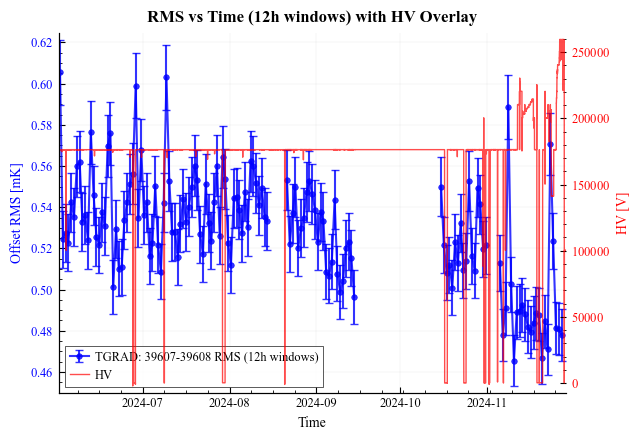


RMS vs HV Analysis complete:
TGRAD: 39607-39608 RMS calculated in 24-hour windows
RMS time range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
HV time range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
Overlap time range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
RMS data points: 180
HV data points: 217438
RMS range: 0.47 - 0.61 mK
HV range: -2192.74 - 259575.66 V


In [254]:
# Plot RMS downsampled at 12h vs datetime with HV on twin axis

# Use the TGRAD pair 39607-39608 for RMS calculation
tgrad_sensor_pairs = [(39607, 39608)]  # TGRAD (Valencia)

# Calculate differences for TGRAD pair
tgrad_differences = {}
for sensor_id_1, sensor_id_2 in tgrad_sensor_pairs:
    sensor1 = tgrad.sensors[sensor_id_1]
    sensor2 = tgrad.sensors[sensor_id_2]
    tgrad_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

# Get time index
time_index = tgrad_differences[list(tgrad_differences.keys())[0]].index

# Define window size (12 hours)
window_size_minutes = 24 * 60  # 12 hours in minutes
window_td = pd.Timedelta(minutes=window_size_minutes)

# Calculate total duration and number of windows
total_duration = time_index[-1] - time_index[0]
num_windows = int(total_duration.total_seconds() / (window_size_minutes * 60))

print(f"RMS vs HV Analysis:")
print(f"Total duration: {total_duration.total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Number of windows: {num_windows}")

# Calculate RMS for each 12-hour window
rms_values_mK = []
rms_errors_mK = []
window_centers = []

for window_idx in range(num_windows):
    # Calculate window start and end times
    window_start = time_index[0] + pd.Timedelta(minutes=window_idx * window_size_minutes)
    window_end = window_start + window_td

    # Ensure we don't go beyond the data range
    if window_end > time_index[-1]:
        window_end = time_index[-1]

    # Get data in this window
    mask = (time_index >= window_start) & (time_index < window_end)

    # Calculate center time of the window for plotting
    window_center_time = window_start + (window_end - window_start) / 2
    window_centers.append(window_center_time)

    # Calculate RMS for TGRAD pair
    pair_id = list(tgrad_differences.keys())[0]
    window_data = tgrad_differences[pair_id][mask]

    if len(window_data) > 0:
        rms_val = window_data.std()
        rms_error = rms_val / np.sqrt(len(window_data))

        # Filter out values larger than 10 mK
        if rms_val <= 0.01:  # 10 mK = 0.01 K
            rms_values_mK.append(rms_val * 1000)  # Convert to mK
            rms_errors_mK.append(rms_error * 1000)  # Convert to mK
        else:
            rms_values_mK.append(np.nan)
            rms_errors_mK.append(np.nan)
    else:
        rms_values_mK.append(np.nan)
        rms_errors_mK.append(np.nan)

# Convert to numpy arrays
rms_values_mK = np.array(rms_values_mK)
rms_errors_mK = np.array(rms_errors_mK)
window_centers = np.array(window_centers)

# Get HV data for the same time range
# Find the overlap between RMS time range and HV data
hv_start = max(time_index[0], hv.data.index[0])
hv_end = min(time_index[-1], hv.data.index[-1])

# Filter HV data to the overlapping time range
hv_mask = (hv.data.index >= hv_start) & (hv.data.index <= hv_end)
hv_data_filtered = hv.data[hv_mask]

print(f"HV data range: {hv.data.index[0]} to {hv.data.index[-1]}")
print(f"Overlap range: {hv_start} to {hv_end}")
print(f"HV data points in overlap: {len(hv_data_filtered)}")

# Create the plot with twin axes
fig, ax1 = plt.subplots(1, 1)

# Plot RMS on left Y-axis
color1 = 'blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Offset RMS [mK]', color=color1)
ax1.errorbar(window_centers, rms_values_mK, yerr=rms_errors_mK,
           fmt='o-', markersize=4, capsize=3, capthick=1, alpha=0.8, color=color1,
           label='TGRAD: 39607-39608 RMS (12h windows)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create twin axis for HV
ax2 = ax1.twinx()
color2 = 'red'
ax2.set_ylabel('HV [V]', color=color2)
ax2.plot(hv_data_filtered.index, hv_data_filtered.values,
         color=color2, alpha=0.7, linewidth=1, label='HV')
ax2.tick_params(axis='y', labelcolor=color2)


# Set time range to show the overlap
ax1.set_xlim(hv_start, hv_end)

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

# Add title
plt.title('RMS vs Time (12h windows) with HV Overlay')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nRMS vs HV Analysis complete:")
print(f"TGRAD: 39607-39608 RMS calculated in {window_size_minutes//60}-hour windows")
print(f"RMS time range: {time_index[0]} to {time_index[-1]}")
print(f"HV time range: {hv.data.index[0]} to {hv.data.index[-1]}")
print(f"Overlap time range: {hv_start} to {hv_end}")
print(f"RMS data points: {len(rms_values_mK)}")
print(f"HV data points: {len(hv_data_filtered)}")
print(f"RMS range: {np.nanmin(rms_values_mK):.2f} - {np.nanmax(rms_values_mK):.2f} mK")
print(f"HV range: {hv_data_filtered.min():.2f} - {hv_data_filtered.max():.2f} V")


RMS Analysis:
Total duration: 4344.0 hours
Window size: 24 hours
Number of windows: 180


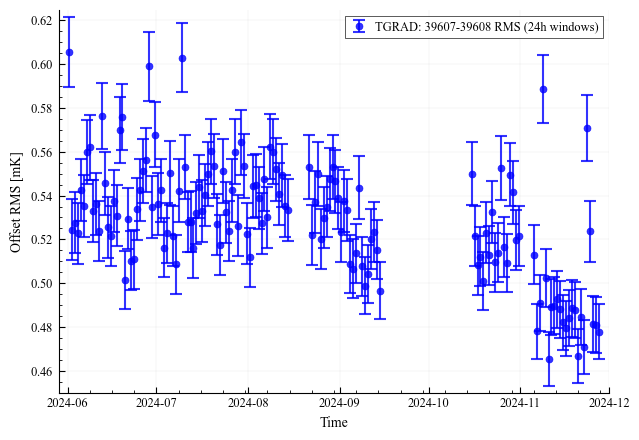


RMS Analysis complete:
TGRAD: 39607-39608 RMS calculated in 24-hour windows
Time range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
Duration: 4344.0 hours
Data points: 180
Valid data points: 140
RMS range: 0.47 - 0.61 mK
Mean RMS: 0.53 mK
Std RMS: 0.03 mK


In [255]:
# Plot RMS downsampled at 12h vs datetime (single axis)

# Use the TGRAD pair 39607-39608 for RMS calculation
tgrad_sensor_pairs = [(39607, 39608)]  # TGRAD (Valencia)

# Calculate differences for TGRAD pair
tgrad_differences = {}
for sensor_id_1, sensor_id_2 in tgrad_sensor_pairs:
    sensor1 = tgrad.sensors[sensor_id_1]
    sensor2 = tgrad.sensors[sensor_id_2]
    tgrad_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

# Get time index
time_index = tgrad_differences[list(tgrad_differences.keys())[0]].index

# Define window size (12 hours)
window_size_minutes = 24 * 60  # 12 hours in minutes
window_td = pd.Timedelta(minutes=window_size_minutes)

# Calculate total duration and number of windows
total_duration = time_index[-1] - time_index[0]
num_windows = int(total_duration.total_seconds() / (window_size_minutes * 60))

print(f"RMS Analysis:")
print(f"Total duration: {total_duration.total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Number of windows: {num_windows}")

# Calculate RMS for each 12-hour window
rms_values_mK = []
rms_errors_mK = []
window_centers = []

for window_idx in range(num_windows):
    # Calculate window start and end times
    window_start = time_index[0] + pd.Timedelta(minutes=window_idx * window_size_minutes)
    window_end = window_start + window_td

    # Ensure we don't go beyond the data range
    if window_end > time_index[-1]:
        window_end = time_index[-1]

    # Get data in this window
    mask = (time_index >= window_start) & (time_index < window_end)

    # Calculate center time of the window for plotting
    window_center_time = window_start + (window_end - window_start) / 2
    window_centers.append(window_center_time)

    # Calculate RMS for TGRAD pair
    pair_id = list(tgrad_differences.keys())[0]
    window_data = tgrad_differences[pair_id][mask]

    if len(window_data) > 0:
        rms_val = window_data.std()
        rms_error = rms_val / np.sqrt(len(window_data))

        # Filter out values larger than 10 mK
        if rms_val <= 0.01:  # 10 mK = 0.01 K
            rms_values_mK.append(rms_val * 1000)  # Convert to mK
            rms_errors_mK.append(rms_error * 1000)  # Convert to mK
        else:
            rms_values_mK.append(np.nan)
            rms_errors_mK.append(np.nan)
    else:
        rms_values_mK.append(np.nan)
        rms_errors_mK.append(np.nan)

# Convert to numpy arrays
rms_values_mK = np.array(rms_values_mK)
rms_errors_mK = np.array(rms_errors_mK)
window_centers = np.array(window_centers)

# Create the plot
fig, ax = plt.subplots(1, 1)

# Plot RMS
ax.errorbar(window_centers, rms_values_mK, yerr=rms_errors_mK,
           fmt='o', markersize=5, capsize=4, capthick=1.5, alpha=0.8, color='blue',
           label='TGRAD: 39607-39608 RMS (24h windows)')

# Formatting
ax.set_xlabel('Time')
ax.set_ylabel('Offset RMS [mK]')
ax.grid(True, alpha=0.3)
ax.legend()

# Add title
# plt.title('RMS vs Time (12h windows)')

plt.tight_layout()
plt.show()

fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/CALIBRATION/performance_aging_all.png")

# Summary statistics
print(f"\nRMS Analysis complete:")
print(f"TGRAD: 39607-39608 RMS calculated in {window_size_minutes//60}-hour windows")
print(f"Time range: {time_index[0]} to {time_index[-1]}")
print(f"Duration: {(time_index[-1] - time_index[0]).total_seconds()/3600:.1f} hours")
print(f"Data points: {len(rms_values_mK)}")
print(f"Valid data points: {np.sum(~np.isnan(rms_values_mK))}")
print(f"RMS range: {np.nanmin(rms_values_mK):.2f} - {np.nanmax(rms_values_mK):.2f} mK")
print(f"Mean RMS: {np.nanmean(rms_values_mK):.2f} mK")
print(f"Std RMS: {np.nanstd(rms_values_mK):.2f} mK")


Found 2 TGRAD sensors below 500mm
Found 4 HAWAI sensors below 500mm
TGRAD pairs: 1
HAWAI pairs: 1
Total duration: 1128.0 hours
Window size: 720 minutes
Number of windows: 93


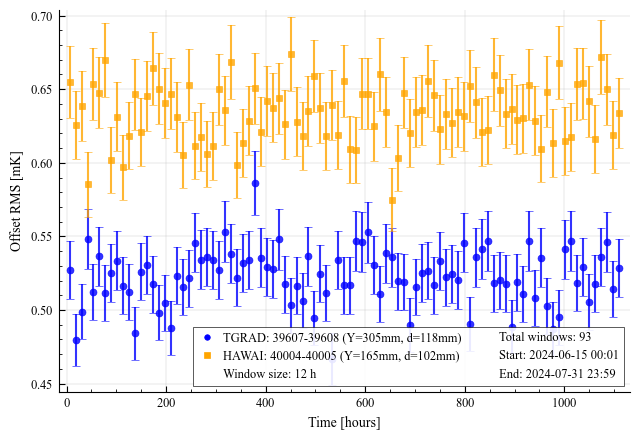


Analysis complete for specific sensor pairs:
TGRAD: 39607-39608 (Bottom height: 305mm, Distance: 118mm)
HAWAI: 40004-40005 (Bottom height: 165mm, Distance: 102mm)
Total time range: 2024-06-15 00:01:00 to 2024-07-31 23:59:00
Duration: 1128.0 hours
Window size: 12 hours
Total windows: 93
Each point represents RMS vs time in 12-hour windows


In [172]:
# Calculate cumulative RMS vs time for all sensor pairs below 1000mm Y coordinate
# For both TGRAD and HAWAI systems

# Filter sensors by Y coordinate (below 1000mm)
y_max = 500

# TGRAD sensors below 1000mm
tgrad_valid_sensors = {}
for sensor_id, sensor in tgrad.sensors.items():
    if sensor.Y < y_max:
        tgrad_valid_sensors[sensor_id] = sensor

# HAWAI sensors below 1000mm
hawai_valid_sensors = {}
for sensor_id, sensor in hawai.sensors.items():
    if sensor.Y < y_max:
        hawai_valid_sensors[sensor_id] = sensor

print(f"Found {len(tgrad_valid_sensors)} TGRAD sensors below {y_max}mm")
print(f"Found {len(hawai_valid_sensors)} HAWAI sensors below {y_max}mm")

# Define specific sensor pairs
tgrad_sensor_pairs = [(39607, 39608)]  # TGRAD (Valencia)
hawai_sensor_pairs = [(40004, 40005)]  # HAWAI

# Calculate sensor information for legend
def get_sensor_info(system, pair_id):
    sensor1 = system.sensors[pair_id[0]]
    sensor2 = system.sensors[pair_id[1]]

    # Find bottom-most sensor (lowest Y coordinate)
    if sensor1.Y < sensor2.Y:
        bottom_sensor = sensor1
        bottom_height = sensor1.Y
    else:
        bottom_sensor = sensor2
        bottom_height = sensor2.Y

    # Calculate distance between sensors
    distance = np.sqrt((sensor1.X - sensor2.X)**2 + (sensor1.Y - sensor2.Y)**2 + (sensor1.Z - sensor2.Z)**2)

    return bottom_height, distance

# Get sensor information
tgrad_bottom_height, tgrad_distance = get_sensor_info(tgrad, tgrad_sensor_pairs[0])
hawai_bottom_height, hawai_distance = get_sensor_info(hawai, hawai_sensor_pairs[0])

print(f"TGRAD pairs: {len(tgrad_sensor_pairs)}")
print(f"HAWAI pairs: {len(hawai_sensor_pairs)}")

# Calculate differences for all pairs
tgrad_differences = {}
for sensor_id_1, sensor_id_2 in tgrad_sensor_pairs:
    sensor1 = tgrad_valid_sensors[sensor_id_1]
    sensor2 = tgrad_valid_sensors[sensor_id_2]
    tgrad_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

hawai_differences = {}
for sensor_id_1, sensor_id_2 in hawai_sensor_pairs:
    sensor1 = hawai_valid_sensors[sensor_id_1]
    sensor2 = hawai_valid_sensors[sensor_id_2]
    hawai_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

# Get time index (use TGRAD as reference)
if len(tgrad_differences) > 0:
    first_tgrad_pair = list(tgrad_differences.keys())[0]
    time_index = tgrad_differences[first_tgrad_pair].index
elif len(hawai_differences) > 0:
    first_hawai_pair = list(hawai_differences.keys())[0]
    time_index = hawai_differences[first_hawai_pair].index
else:
    raise ValueError("No valid sensor pairs found")

# Calculate total duration in minutes
total_duration_minutes = (time_index[-1] - time_index[0]).total_seconds() / 60
total_duration_hours = total_duration_minutes / 60

# Define time windows (in minutes) - include the full duration
base_windows = [30, 60, 90, 120, 180, 240, 360, 480, 720, 1440]  # minutes

# Add more windows to cover the full duration
time_windows = base_windows.copy()

# Add windows up to the total duration
if total_duration_minutes > 1440:
    # Add 6-hour intervals up to 24 hours
    for hours in range(6, 25, 6):
        minutes = hours * 60
        if minutes <= total_duration_minutes and minutes not in time_windows:
            time_windows.append(minutes)

    # Add 12-hour intervals from 24 hours to total duration
    for hours in range(24, int(total_duration_hours) + 1, 12):
        minutes = hours * 60
        if minutes <= total_duration_minutes and minutes not in time_windows:
            time_windows.append(minutes)

# Always include the full duration as the last point
if int(total_duration_minutes) not in time_windows:
    time_windows.append(int(total_duration_minutes))

# Sort the windows
time_windows = sorted(time_windows)

# Calculate RMS in sliding time windows for all pairs
tgrad_all_rms_results = {}
hawai_all_rms_results = {}

# Define window size (12 hours)
window_size_minutes = 12 * 60  # 12 hours in minutes
window_td = pd.Timedelta(minutes=window_size_minutes)

# Calculate total duration and number of windows
total_duration = time_index[-1] - time_index[0]
num_windows = int(total_duration.total_seconds() / (window_size_minutes * 60))

print(f"Total duration: {total_duration.total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes} minutes")
print(f"Number of windows: {num_windows}")

# Calculate RMS for each sliding window
for window_idx in range(num_windows):
    # Calculate window start and end times
    window_start = time_index[0] + pd.Timedelta(minutes=window_idx * window_size_minutes)
    window_end = window_start + window_td

    # Ensure we don't go beyond the data range
    if window_end > time_index[-1]:
        window_end = time_index[-1]

    # Get data in this window
    mask = (time_index >= window_start) & (time_index < window_end)

    # Calculate center time of the window for plotting
    window_center_time = window_start + (window_end - window_start) / 2
    window_center_hours = (window_center_time - time_index[0]).total_seconds() / 3600

    # TGRAD calculation for all pairs
    tgrad_rms_results = {}
    for pair_id, sensor_diff in tgrad_differences.items():
        window_data = sensor_diff[mask]
        if len(window_data) > 0:
            rms_val = window_data.std()
            rms_error = rms_val / np.sqrt(len(window_data))

            # Filter out values larger than 10 mK
            if rms_val <= 0.01:  # 10 mK = 0.01 K
                tgrad_rms_results[pair_id] = {
                    'rms_value': rms_val,
                    'rms_error': rms_error,
                    'data_points': len(window_data),
                    'window_center_hours': window_center_hours
                }

    tgrad_all_rms_results[window_idx] = tgrad_rms_results

    # HAWAI calculation for all pairs
    hawai_rms_results = {}
    for pair_id, sensor_diff in hawai_differences.items():
        window_data = sensor_diff[mask]
        if len(window_data) > 0:
            rms_val = window_data.std()
            rms_error = rms_val / np.sqrt(len(window_data))

            # Filter out values larger than 10 mK
            if rms_val <= 0.01:  # 10 mK = 0.01 K
                hawai_rms_results[pair_id] = {
                    'rms_value': rms_val,
                    'rms_error': rms_error,
                    'data_points': len(window_data),
                    'window_center_hours': window_center_hours
                }

    hawai_all_rms_results[window_idx] = hawai_rms_results

# Create plot: RMS vs Time for all sensor pairs
fig, ax = plt.subplots(1, 1)

# Prepare data for plotting - get time points from the first window that has data
time_points_hours = []
for window_idx in range(num_windows):
    if window_idx in tgrad_all_rms_results and len(tgrad_all_rms_results[window_idx]) > 0:
        # Get time from first available pair
        first_pair = list(tgrad_all_rms_results[window_idx].keys())[0]
        time_points_hours.append(tgrad_all_rms_results[window_idx][first_pair]['window_center_hours'])
    elif window_idx in hawai_all_rms_results and len(hawai_all_rms_results[window_idx]) > 0:
        # Get time from first available pair
        first_pair = list(hawai_all_rms_results[window_idx].keys())[0]
        time_points_hours.append(hawai_all_rms_results[window_idx][first_pair]['window_center_hours'])

# Define simple colors and markers for each system
tgrad_color = 'blue'
hawai_color = 'orange'

# Plot TGRAD data - one point per sensor pair
for i, pair_id in enumerate(tgrad_sensor_pairs):
    rms_values_mK = []
    rms_errors_mK = []
    time_points = []

    for window_idx in range(num_windows):
        if window_idx in tgrad_all_rms_results and pair_id in tgrad_all_rms_results[window_idx]:
            data = tgrad_all_rms_results[window_idx][pair_id]
            rms_values_mK.append(data['rms_value'] * 1000)  # Convert to mK
            rms_errors_mK.append(data['rms_error'] * 1000)  # Convert to mK
            time_points.append(data['window_center_hours'])
        else:
            rms_values_mK.append(np.nan)
            rms_errors_mK.append(np.nan)
            time_points.append(np.nan)

    # Only plot if we have valid data
    if not all(np.isnan(rms_values_mK)):
        ax.errorbar(time_points, rms_values_mK, yerr=rms_errors_mK,
                   fmt='o', alpha=0.8, markersize=5, color=tgrad_color,
                   label=f'TGRAD: 39607-39608 (Y={tgrad_bottom_height:.0f}mm, d={tgrad_distance:.0f}mm)' if i == 0 else "")

# Plot HAWAI data - one point per sensor pair
for i, pair_id in enumerate(hawai_sensor_pairs):
    rms_values_mK = []
    rms_errors_mK = []
    time_points = []

    for window_idx in range(num_windows):
        if window_idx in hawai_all_rms_results and pair_id in hawai_all_rms_results[window_idx]:
            data = hawai_all_rms_results[window_idx][pair_id]
            rms_values_mK.append(data['rms_value'] * 1000)  # Convert to mK
            rms_errors_mK.append(data['rms_error'] * 1000)  # Convert to mK
            time_points.append(data['window_center_hours'])
        else:
            rms_values_mK.append(np.nan)
            rms_errors_mK.append(np.nan)
            time_points.append(np.nan)

    # Only plot if we have valid data
    if not all(np.isnan(rms_values_mK)):
        ax.errorbar(time_points, rms_values_mK, yerr=rms_errors_mK,
                   fmt='s', alpha=0.8, markersize=5, color=hawai_color,
                   label=f'HAWAI: 40004-40005 (Y={hawai_bottom_height:.0f}mm, d={hawai_distance:.0f}mm)' if i == 0 else "")

# Formatting
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Offset RMS [mK]')
ax.grid(True)

# Add statistics to legend
total_duration_hours = (time_index[-1] - time_index[0]).total_seconds()/3600

# Create legend with statistics
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', linestyle='None',
               label=f'TGRAD: 39607-39608 (Y={tgrad_bottom_height:.0f}mm, d={tgrad_distance:.0f}mm)'),
    plt.Line2D([0], [0], color='orange', marker='s', linestyle='None',
               label=f'HAWAI: 40004-40005 (Y={hawai_bottom_height:.0f}mm, d={hawai_distance:.0f}mm)'),
    plt.Line2D([0], [0], color='none', label=f'Window size: {window_size_minutes//60} h'),
    plt.Line2D([0], [0], color='none', label=f'Total windows: {num_windows}'),
    plt.Line2D([0], [0], color='none', label=f'Start: {time_index[0].strftime("%Y-%m-%d %H:%M")}'),
    plt.Line2D([0], [0], color='none', label=f'End: {time_index[-1].strftime("%Y-%m-%d %H:%M")}')
]

ax.legend(handles=legend_elements, loc='best', ncol=2)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nAnalysis complete for specific sensor pairs:")
print(f"TGRAD: 39607-39608 (Bottom height: {tgrad_bottom_height:.0f}mm, Distance: {tgrad_distance:.0f}mm)")
print(f"HAWAI: 40004-40005 (Bottom height: {hawai_bottom_height:.0f}mm, Distance: {hawai_distance:.0f}mm)")
print(f"Total time range: {time_index[0]} to {time_index[-1]}")
print(f"Duration: {(time_index[-1] - time_index[0]).total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Total windows: {num_windows}")
print(f"Each point represents RMS vs time in {window_size_minutes//60}-hour windows")

fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/CALIBRATION/performance_aging_first.png", dpi=300, format="png")


In [198]:
dataset = baseClasses.Data()

In [210]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 1)) & (dataset.data.index < datetime.datetime(2024, 9, 15))) |
    ((dataset.data.index > datetime.datetime(2024, 10, 15)) & (dataset.data.index < datetime.datetime(2024, 11, 29)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [211]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")

Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing HAWAI Sensors: 100%|██████████| 24/24 [00:03<00:00,  7.37sensor/s]


In [212]:
tgrad.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_OCTOBER")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.43sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 80.59sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00,  8.69sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_OCTOBER:  83%|████████▎ | 20/24 [00:00<00:00, 94.87sensor/s]

ERROR: SensorID (40000) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40001) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40002) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40003) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40004) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40005) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40006) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40007) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40008) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40009) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40010) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40011) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40012) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40013) not found in calibration (SECOND_POFF_OCTOBER)
ERROR:

Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 24/24 [00:00<00:00, 87.36sensor/s]

ERROR: SensorID (40020) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40021) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40022) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40023) not found in calibration (SECOND_POFF_OCTOBER)


TGRAD Analysis:
Total duration: 4344.0 hours
Window size: 12 hours
Number of windows: 361


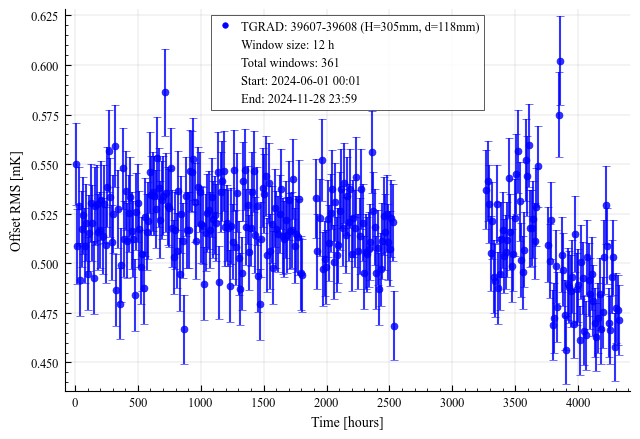


TGRAD Analysis complete:
TGRAD: 39607-39608 (Bottom height: 305mm, Distance: 118mm)
Total time range: 2024-06-01 00:01:00 to 2024-11-28 23:59:00
Duration: 4344.0 hours
Window size: 12 hours
Total windows: 361
Each point represents RMS vs time in 12-hour windows


In [214]:
# Plot only TGRAD sensor pair (39607-39608)

# Define TGRAD sensor pair
tgrad_sensor_pairs = [(39607, 39608)]  # TGRAD (Valencia)

# Calculate sensor information for legend
def get_sensor_info(system, pair_id):
    sensor1 = system.sensors[pair_id[0]]
    sensor2 = system.sensors[pair_id[1]]

    # Find bottom-most sensor (lowest Y coordinate)
    if sensor1.Y < sensor2.Y:
        bottom_sensor = sensor1
        bottom_height = sensor1.Y
    else:
        bottom_sensor = sensor2
        bottom_height = sensor2.Y

    # Calculate distance between sensors
    distance = np.sqrt((sensor1.X - sensor2.X)**2 + (sensor1.Y - sensor2.Y)**2 + (sensor1.Z - sensor2.Z)**2)

    return bottom_height, distance

# Get sensor information
tgrad_bottom_height, tgrad_distance = get_sensor_info(tgrad, tgrad_sensor_pairs[0])

# Calculate differences for TGRAD pair
tgrad_differences = {}
for sensor_id_1, sensor_id_2 in tgrad_sensor_pairs:
    sensor1 = tgrad.sensors[sensor_id_1]
    sensor2 = tgrad.sensors[sensor_id_2]
    tgrad_differences[(sensor_id_1, sensor_id_2)] = sensor1.data - sensor2.data

# Get time index
time_index = tgrad_differences[list(tgrad_differences.keys())[0]].index

# Define window size (12 hours)
window_size_minutes = 12 * 60  # 12 hours in minutes
window_td = pd.Timedelta(minutes=window_size_minutes)

# Calculate total duration and number of windows
total_duration = time_index[-1] - time_index[0]
num_windows = int(total_duration.total_seconds() / (window_size_minutes * 60))

print(f"TGRAD Analysis:")
print(f"Total duration: {total_duration.total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Number of windows: {num_windows}")

# Calculate RMS for each sliding window
tgrad_all_rms_results = {}

for window_idx in range(num_windows):
    # Calculate window start and end times
    window_start = time_index[0] + pd.Timedelta(minutes=window_idx * window_size_minutes)
    window_end = window_start + window_td

    # Ensure we don't go beyond the data range
    if window_end > time_index[-1]:
        window_end = time_index[-1]

    # Get data in this window
    mask = (time_index >= window_start) & (time_index < window_end)

    # Calculate center time of the window for plotting
    window_center_time = window_start + (window_end - window_start) / 2
    window_center_hours = (window_center_time - time_index[0]).total_seconds() / 3600

    # TGRAD calculation
    tgrad_rms_results = {}
    for pair_id, sensor_diff in tgrad_differences.items():
        window_data = sensor_diff[mask]
        if len(window_data) > 0:
            rms_val = window_data.std()
            rms_error = rms_val / np.sqrt(len(window_data))

            # Filter out values larger than 10 mK
            if rms_val <= 0.01:  # 10 mK = 0.01 K
                tgrad_rms_results[pair_id] = {
                    'rms_value': rms_val,
                    'rms_error': rms_error,
                    'data_points': len(window_data),
                    'window_center_hours': window_center_hours
                }

    tgrad_all_rms_results[window_idx] = tgrad_rms_results

# Create plot: RMS vs Time for TGRAD only
fig, ax = plt.subplots(1, 1)

# Define color for TGRAD
tgrad_color = 'blue'

# Plot TGRAD data
for i, pair_id in enumerate(tgrad_sensor_pairs):
    rms_values_mK = []
    rms_errors_mK = []
    time_points = []

    for window_idx in range(num_windows):
        if window_idx in tgrad_all_rms_results and pair_id in tgrad_all_rms_results[window_idx]:
            data = tgrad_all_rms_results[window_idx][pair_id]
            rms_values_mK.append(data['rms_value'] * 1000)  # Convert to mK
            rms_errors_mK.append(data['rms_error'] * 1000)  # Convert to mK
            time_points.append(data['window_center_hours'])
        else:
            rms_values_mK.append(np.nan)
            rms_errors_mK.append(np.nan)
            time_points.append(np.nan)

    # Only plot if we have valid data
    if not all(np.isnan(rms_values_mK)):
        ax.errorbar(time_points, rms_values_mK, yerr=rms_errors_mK,
                   fmt='o', alpha=0.8, markersize=5, color=tgrad_color,
                   label=f'TGRAD: 39607-39608 (H={tgrad_bottom_height:.0f}mm, d={tgrad_distance:.0f}mm)')

# Formatting
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Offset RMS [mK]')
ax.grid(True)

# Create legend with statistics
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', linestyle='None',
               label=f'TGRAD: 39607-39608 (H={tgrad_bottom_height:.0f}mm, d={tgrad_distance:.0f}mm)'),
    plt.Line2D([0], [0], color='none', label=f'Window size: {window_size_minutes//60} h'),
    plt.Line2D([0], [0], color='none', label=f'Total windows: {num_windows}'),
    plt.Line2D([0], [0], color='none', label=f'Start: {time_index[0].strftime("%Y-%m-%d %H:%M")}'),
    plt.Line2D([0], [0], color='none', label=f'End: {time_index[-1].strftime("%Y-%m-%d %H:%M")}')
]

ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nTGRAD Analysis complete:")
print(f"TGRAD: 39607-39608 (Bottom height: {tgrad_bottom_height:.0f}mm, Distance: {tgrad_distance:.0f}mm)")
print(f"Total time range: {time_index[0]} to {time_index[-1]}")
print(f"Duration: {(time_index[-1] - time_index[0]).total_seconds()/3600:.1f} hours")
print(f"Window size: {window_size_minutes//60} hours")
print(f"Total windows: {num_windows}")
print(f"Each point represents RMS vs time in {window_size_minutes//60}-hour windows")


Text(0, 0.5, 'Temperature [K]')

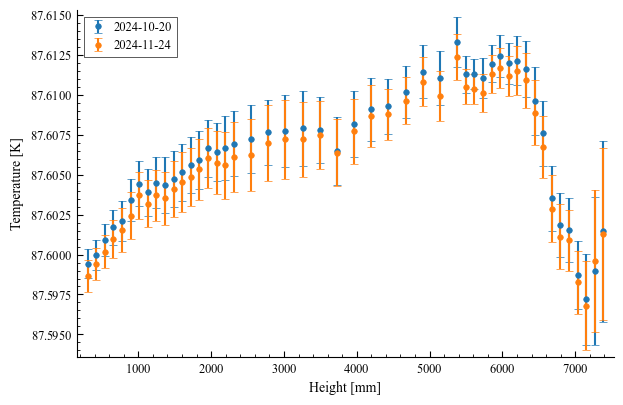

In [224]:
fig, axes = plt.subplots(1, 1)
tgrad.makeProfiles(tini=datetime.datetime(2024, 10, 20), tend=datetime.datetime(2024, 10, 20, 12))
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"2024-10-20")
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 24), tend=datetime.datetime(2024, 11, 24, 12))
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"2024-11-24")
axes.legend()
axes.set_xlabel(r"Height [mm]")
axes.set_ylabel(r"Temperature [K]")


In [241]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
hv = sensorClasses.Sensor(dataset=dataset, id=1013)
hvi = sensorClasses.Sensor(dataset=dataset, id=1014)
cryostat_height = 8550.4

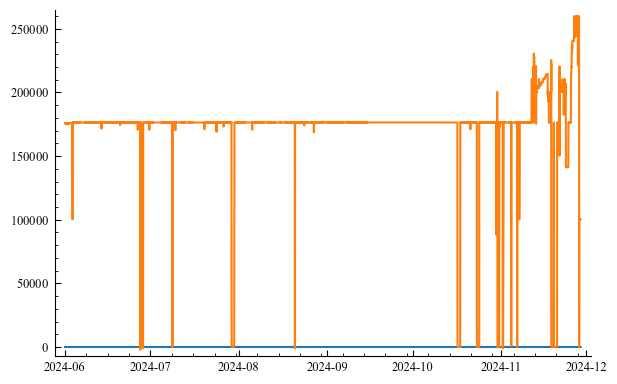

In [ ]:
fig, axes = plt.subplots(1, 1)
# axes.plot(pressure1.data.index, pressure1.data.values, label="Pressure 1")
# axes.plot(pressure2.data.index, pressure2.data.values, label="Pressure 2")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values, label="Ambient Pressure")
# axes.plot(pump_pressure.data.index, pump_pressure.data.values, ".", label="Pump Pressure")
# axes.plot(lar_pressure1.data.index, lar_pressure1.data.values, label="Lar 1")
# axes.plot(lar_flow.data.index, lar_flow.data.values, label="Lar Flow")
# axes.plot(level1.data.index, level1.data.values, label="Level 1")
# axes.plot(level2.data.index, level2.data.values, label="Level 2")
# axes.plot(lar_pressure2.data.index, lar_pressure2.data.values, label="Lar 2")
axes.plot(hv.data.index, hv.data.values, label="HV")
# axes.set_xlim(datetime.datetime(2024, 10, 15), datetime.datetime(2024, 11, 29))
# axes.set_ylim(2.5, 3)

